In [103]:
#資料處理Lib
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import datetime as dt   #用於處理時間格式

#用來畫圖的Lib
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 20,10

In [65]:
#讀取excel資料
#EPS = pd.read_excel("Eps01.xlsx")
Price = pd.read_excel("Price01.xlsx")
TSMC = pd.read_excel("2330.xlsx")

### 台積電財報

In [66]:
TSMC.describe()

#可以幫忙把常用的統計量算出
# Count次數, mean平均, std標準差, min最小值

,Ticker,TMP_ID,TKL_ID,QuarterlyRevenue,CostOfGoodsSold,GrossProfit,OPProfit,OPIncomeLoss,PreTaxIncome,NetIncome,...,CCEquivalents,NonCurrentLiab,TotalShareCapital,NetNotesReceivable,PropertyPlantEquip,RightOfUseAsset,InterestExp,TotalNonCurrentAssets,CapitalCost,FreeCashFlow
count,55.0,5.500000e+01,55.0,5.500000e+01,5.500000e+01,5.500000e+01,5.500000e+01,5.500000e+01,5.500000e+01,5.500000e+01,...,5.500000e+01,5.500000e+01,5.500000e+01,0.0,5.500000e+01,1.100000e+01,5.500000e+01,5.500000e+01,0.0,0.0
mean,2330.0,3.231238e+05,271.0,1.945531e+08,9.918349e+07,9.536576e+07,7.377071e+07,2.965378e+06,7.644460e+07,6.788937e+07,...,3.717908e+08,1.265431e+08,2.589766e+08,NaN,1.075596e+09,2.372707e+07,5.529631e+05,8.727249e+08,NaN,NaN
std,0.0,9.673751e+05,0.0,9.249470e+07,4.348765e+07,4.961841e+07,4.036815e+07,2.867976e+06,4.147842e+07,3.660779e+07,...,2.092234e+08,1.221573e+08,8.661878e+05,NaN,2.815428e+08,6.390268e+06,3.358950e+05,4.658230e+08,NaN,NaN
min,2330.0,1.386600e+04,271.0,3.950013e+07,3.201988e+07,7.480242e+06,1.209341e+06,-2.681700e+05,7.484990e+05,1.487727e+06,...,1.124455e+08,7.018550e+05,2.562544e+08,NaN,6.664474e+08,1.723240e+07,8.744600e+04,2.250710e+08,NaN,NaN
25%,2330.0,1.387950e+04,271.0,1.083129e+08,5.699358e+07,5.179841e+07,3.981584e+07,1.604149e+06,4.136129e+07,3.798132e+07,...,1.718813e+08,1.848592e+07,2.591472e+08,NaN,8.408983e+08,1.854293e+07,1.662585e+05,4.754203e+08,NaN,NaN
50%,2330.0,1.389300e+04,271.0,2.035186e+08,1.046080e+08,9.133758e+07,7.071392e+07,2.470109e+06,7.409812e+07,6.479260e+07,...,3.584490e+08,9.978050e+07,2.592966e+08,NaN,1.037364e+09,2.103689e+07,7.323260e+05,8.825573e+08,NaN,NaN
75%,2330.0,1.390650e+04,271.0,2.562276e+08,1.283596e+08,1.253688e+08,9.744169e+07,3.687816e+06,1.002309e+08,8.986840e+07,...,5.637071e+08,2.213189e+08,2.593038e+08,NaN,1.211916e+09,3.000535e+07,8.183555e+05,1.135611e+09,NaN,NaN
max,2330.0,4.269136e+06,271.0,4.146704e+08,2.018217e+08,2.127462e+08,1.710035e+08,2.106262e+07,1.738516e+08,1.564792e+08,...,8.538120e+08,5.983701e+08,2.593038e+08,NaN,1.828895e+09,3.296110e+07,1.334063e+06,1.961673e+09,NaN,NaN


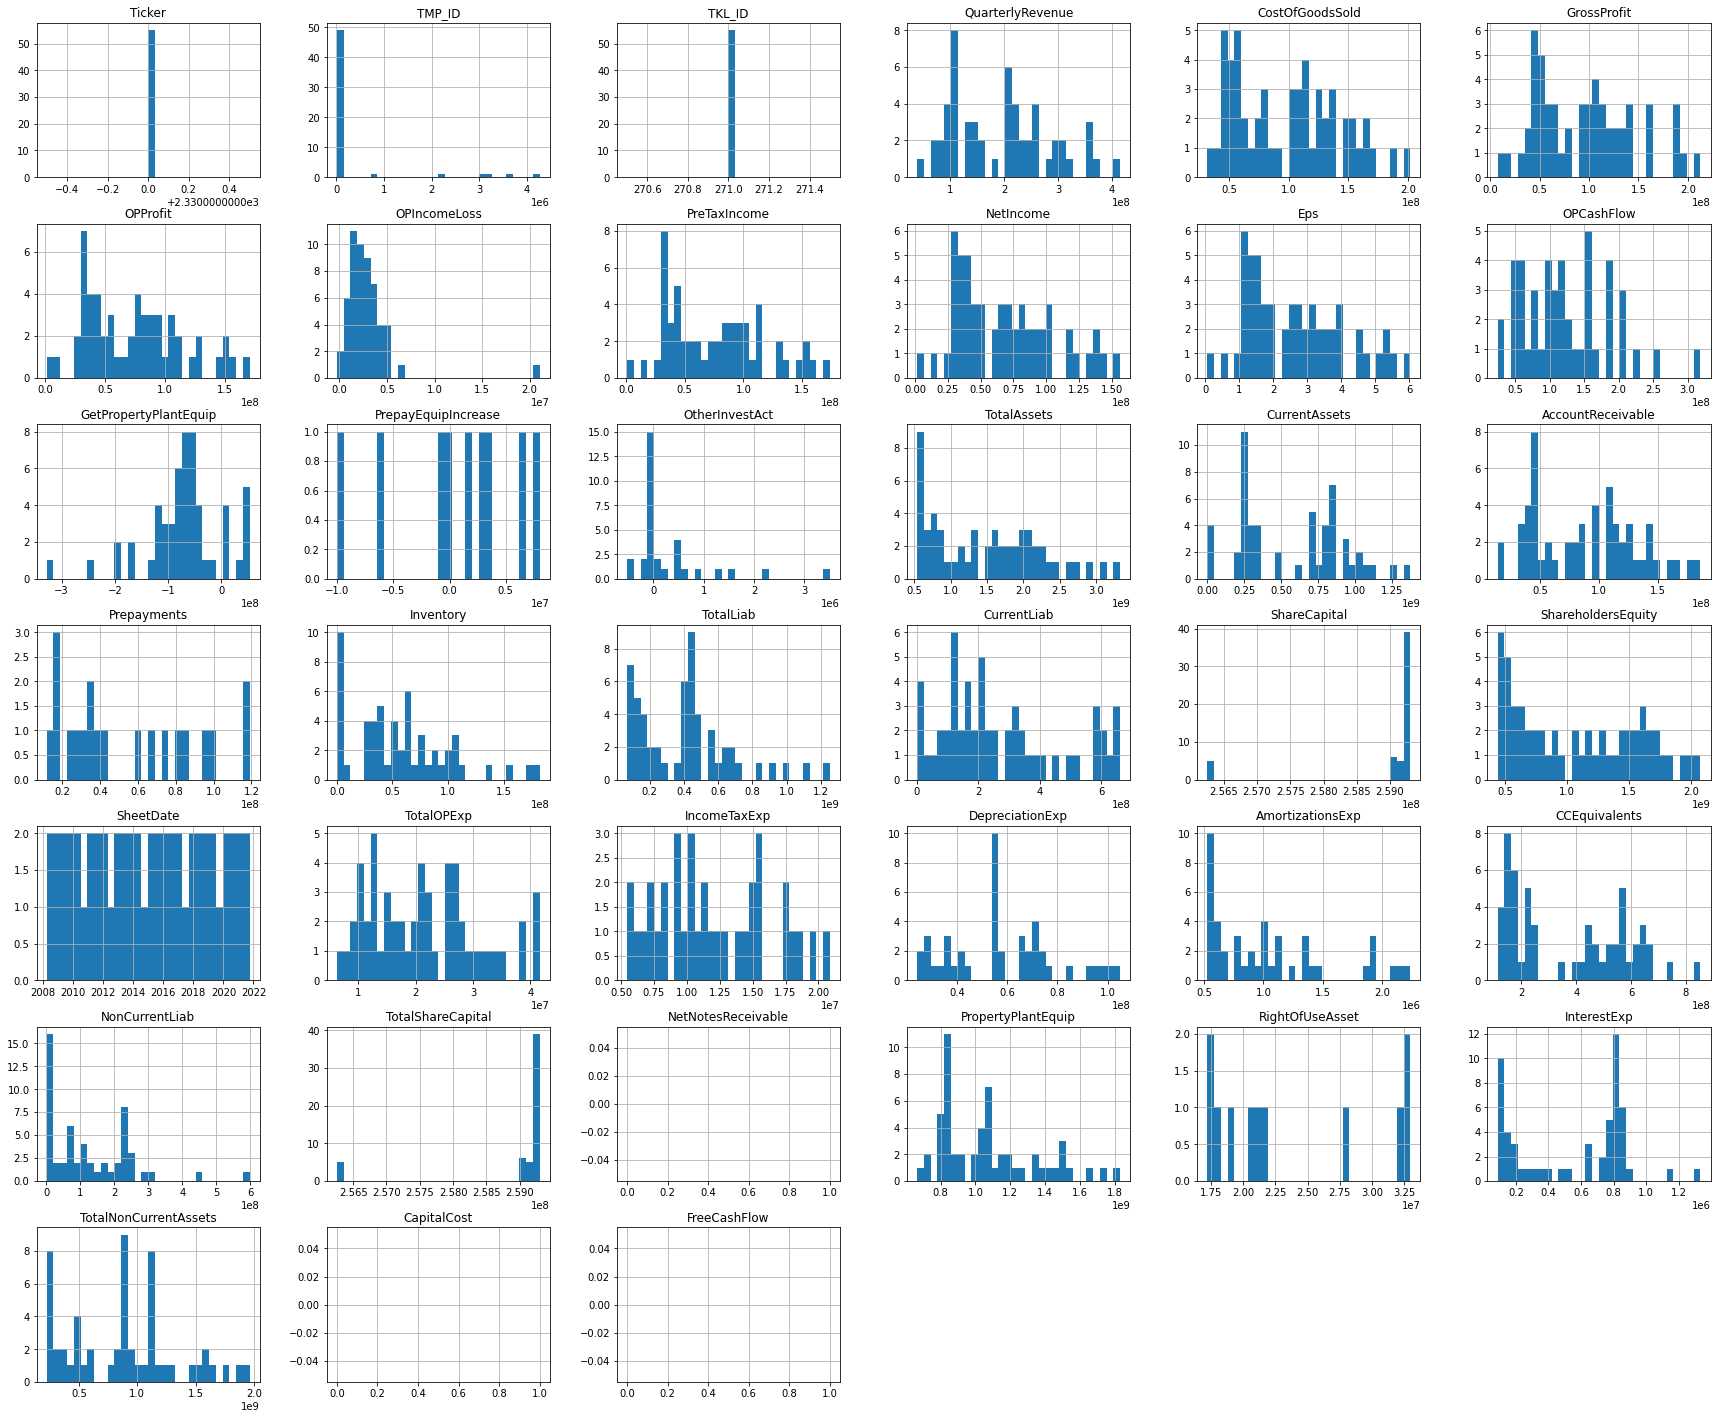

In [136]:
TSMC.hist(bins=30,figsize=(30,25))
plt.show()

#展現出上面數據(coloum)的統計圖表，只有少數幾個有用
#可以快速查看，沒有出現必要

### 股價收益率

In [68]:
#顯示部分數據
Price.head()

#head函數：出現頭幾行

,Ticker,2016-01-29 00:00:00,2016-01-30 00:00:00,2016-02-01 00:00:00,2016-02-02 00:00:00,2016-02-03 00:00:00,2016-02-15 00:00:00,2016-02-16 00:00:00,2016-02-17 00:00:00,2016-02-18 00:00:00,...,2022-04-28 00:00:00,2022-04-29 00:00:00,2022-05-03 00:00:00,2022-05-04 00:00:00,2022-05-05 00:00:00,2022-05-06 00:00:00,2022-05-09 00:00:00,2022-05-10 00:00:00,2022-05-11 00:00:00,2022-05-12 00:00:00
0,2317,77.8,78.20,79.50,78.4,76.60,74.7,76.6,76.70,77.70,...,101.50,102.00,102.5,104.00,104.5,104.00,104,104.00,103.00,102.00
1,2330,143.0,142.00,144.00,142.5,146.00,145.0,147.5,148.00,151.00,...,531.00,538.00,531.0,534.00,542.0,528.00,520,518.00,521.00,505.00
2,2618,17.4,17.55,17.30,17.4,17.15,17.3,17.5,17.65,17.40,...,33.75,35.65,35.5,35.70,35.9,36.20,35,35.70,34.55,31.15
3,3078,21.3,21.70,21.35,21.3,21.35,21.8,21.8,22.50,22.45,...,35.50,35.70,35.7,35.75,35.9,35.85,35,34.95,34.50,33.75


In [69]:
#換名字(Ticker變成Date)
Price1 = Price.rename(columns={'Ticker' : 'Date'})  
Price1

,Date,2016-01-29 00:00:00,2016-01-30 00:00:00,2016-02-01 00:00:00,2016-02-02 00:00:00,2016-02-03 00:00:00,2016-02-15 00:00:00,2016-02-16 00:00:00,2016-02-17 00:00:00,2016-02-18 00:00:00,...,2022-04-28 00:00:00,2022-04-29 00:00:00,2022-05-03 00:00:00,2022-05-04 00:00:00,2022-05-05 00:00:00,2022-05-06 00:00:00,2022-05-09 00:00:00,2022-05-10 00:00:00,2022-05-11 00:00:00,2022-05-12 00:00:00
0,2317,77.8,78.20,79.50,78.4,76.60,74.7,76.6,76.70,77.70,...,101.50,102.00,102.5,104.00,104.5,104.00,104,104.00,103.00,102.00
1,2330,143.0,142.00,144.00,142.5,146.00,145.0,147.5,148.00,151.00,...,531.00,538.00,531.0,534.00,542.0,528.00,520,518.00,521.00,505.00
2,2618,17.4,17.55,17.30,17.4,17.15,17.3,17.5,17.65,17.40,...,33.75,35.65,35.5,35.70,35.9,36.20,35,35.70,34.55,31.15
3,3078,21.3,21.70,21.35,21.3,21.35,21.8,21.8,22.50,22.45,...,35.50,35.70,35.7,35.75,35.9,35.85,35,34.95,34.50,33.75


In [53]:
#檢查是否有空值
Price1.isna().sum().sum()

7

In [54]:
#填空值 : 填入前一個有效值
#使用 ffill方法 = front fill  將前面的數字填入空值
#axis=1 是要程式可以按照coloume的方式去看  (沒寫的話默認=0)
Price2 = Price1.fillna(method='ffill',axis=1)  

In [55]:
Price2.isna().sum().sum()

0

In [105]:
#將Date設為index，並將「矩陣轉置」(用 .T)
#取代上面的index=0,1,2,3,4，這樣上方才不是 0,1,2,3,4

Price3 = Price2.set_index('Date').T

#將時間設為變數，並轉為數值
#因為時間不能直接計算，所以把他換成數字 (用 .map 轉換，數字在後面的Date)

Price3.columns=["2317","2330","2618","3078"]  #重新定義，確保是字串的格式
Price3["date"] = Price3.index                 #新增 Date 的column
Price3['date'] = Price3['date'].map(dt.datetime.toordinal)
Price3.head()

,2317,2330,2618,3078,date
2016-01-29 00:00:00,77.8,143.0,17.40,21.30,735992
2016-01-30 00:00:00,78.2,142.0,17.55,21.70,735993
2016-02-01 00:00:00,79.5,144.0,17.30,21.35,735995
2016-02-02 00:00:00,78.4,142.5,17.40,21.30,735996
2016-02-03 00:00:00,76.6,146.0,17.15,21.35,735997


### 線性迴歸

In [147]:
#切分訓練集與測試集
train = Price3[:987]
valid = Price3[987:]

#取2330股價
x_train = train.drop({'2317','2330','3078','2618'},axis=1)     #留下Date
y_train = train['2330']                                        #預測目標(target)
x_valid = valid.drop({'2317','2330','3078','2618'},axis=1)
y_valid = valid['2330']

In [156]:
x_train

,date
2016-01-29,735992
2016-01-30,735993
2016-02-01,735995
2016-02-02,735996
2016-02-03,735997
...,...
2020-02-12,737467
2020-02-13,737468
2020-02-14,737469
2020-02-17,737472


In [158]:
y_train

2016-01-29    143.0
2016-01-30    142.0
2016-02-01    144.0
2016-02-02    142.5
2016-02-03    146.0
              ...  
2020-02-12    335.0
2020-02-13    335.0
2020-02-14    335.0
2020-02-17    331.5
2020-02-18    322.0
Name: 2330, Length: 987, dtype: float64

In [154]:
#訓練線性迴歸
model = LinearRegression()
model.fit(x_train,y_train)             # .fit 就是定義所用的 LinearRegression函數
print(model.coef_,model.intercept_)    # print出 斜率 & 截距 (按照datetime的那個數據，所以數字很大)

[0.09224552] -67736.7702922144


In [137]:
#預測並求RMS(均分根誤差)
preds = model.predict(x_valid)         #預測模型的效果 preds = prediction

rms=np.sqrt(np.mean(np.power((np.array(y_valid)-np.array(preds)),2)))   #sqrt開根號, power 次方  #裡面 = 驗證-預測
rms                                                                     #未來預測值-驗證級可能可以差到208.96元(非常不准)

208.9622131939556

C:\Users\atrust\AppData\Roaming\Python\Python37\site-packages\ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  
C:\Users\atrust\AppData\Roaming\Python\Python37\site-packages\ipykernel_launcher.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  This is separate from the ipykernel package so we can avoid doing imports until


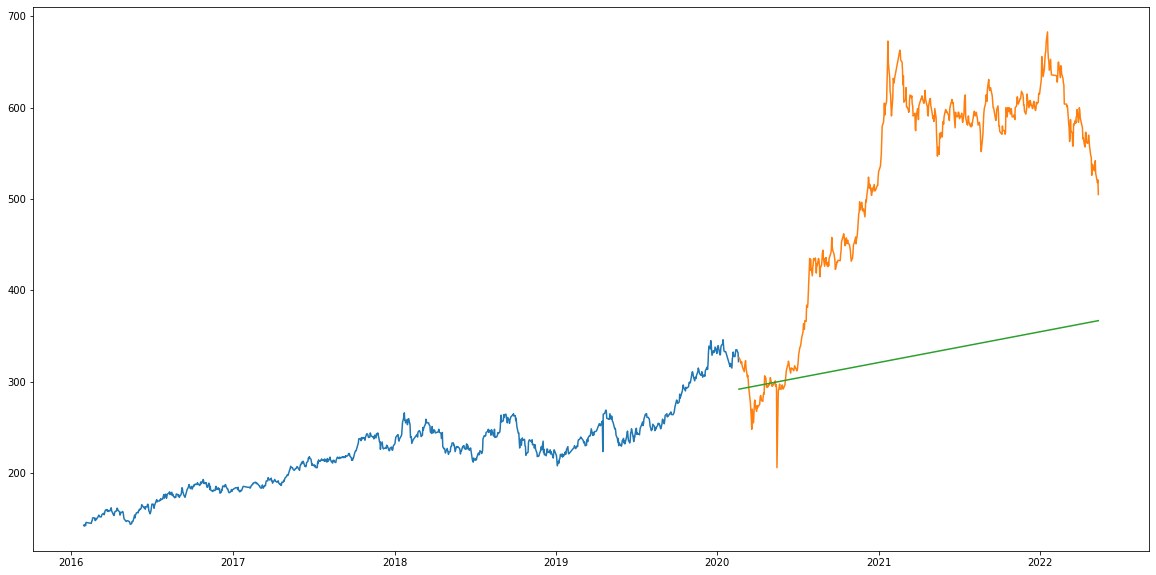

In [150]:
#畫圖
#藍色的是訓練的資料；黃色的是test組的資料；綠色線為 Regression (預測結果)，是藍色線的趨勢

valid['Predictions'] = 0           #在新開一個 Column，叫做 Prediction
valid['Predictions'] = preds


plt.plot(train['2330'])                        #先畫出 Train組的圖
plt.plot(valid[['2330', 'Predictions']])       #同時畫 valid組 和 預測值

In [160]:
valid

,2317,2330,2618,3078,date,Predictions
2020-02-19,83.8,326.5,12.65,24.75,737474,291.903097
2020-02-20,82.8,325.5,12.55,24.50,737475,291.995342
2020-02-21,81.7,325.0,12.35,24.35,737476,292.087588
2020-02-24,80.7,320.0,12.10,24.10,737479,292.364324
2020-02-25,82.3,322.0,12.10,24.15,737480,292.456570
...,...,...,...,...,...,...
2022-05-06,104.0,528.0,36.20,35.85,738281,366.345232
2022-05-09,104.0,520.0,35.00,35.00,738284,366.621969
2022-05-10,104.0,518.0,35.70,34.95,738285,366.714214
2022-05-11,103.0,521.0,34.55,34.50,738286,366.806460
